In [1]:
import pandas as pd
import numpy as np

In [2]:
dataFrame=pd.read_csv('D:/Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning/Dataset/lstm_dataset_1.csv')

In [3]:
dataFrame.columns

Index(['u', 'v', 'length_m', 'timestamp', 'hour', 'day_of_week',
       'current_speed', 'free_flow_speed', 'congestion', 'rain', 'incident',
       'hour_sine', 'hour_cos', 'day_sin', 'day_cos', 'travel_time_log',
       'length_log', 'speed_ratio'],
      dtype='str')

In [4]:
# Step 1: get sorted timestamps
timestamps = np.array(sorted(dataFrame["timestamp"].unique()))

# Step 2: define block size
BLOCK_SIZE = 22+9   # hours (IMPORTANT: >= seq_len+pred_length)

# Step 3: split into blocks
blocks = [timestamps[i:i+BLOCK_SIZE] for i in range(0, len(timestamps), BLOCK_SIZE)]

train_times = []
val_times = []
test_times = []

# Step 4: assign blocks
for i, block in enumerate(blocks):

    if i % 5 in [0, 1, 3]:   # 60% train
        train_times.extend(block)

    elif i % 5 == 2:         # 20% val
        val_times.extend(block)

    else:                    # 20% test
        test_times.extend(block)

# Convert to set (faster lookup)
train_times = set(train_times)
val_times   = set(val_times)
test_times  = set(test_times)

# Step 5: filter dataframe
train_df = dataFrame[dataFrame["timestamp"].isin(train_times)]
val_df   = dataFrame[dataFrame["timestamp"].isin(val_times)]
test_df  = dataFrame[dataFrame["timestamp"].isin(test_times)]

print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))

Train size: 15254354
Val size: 4461179
Test size: 4461179


In [5]:
train_df['day_of_week'].unique()

array([0, 1, 2, 3, 4, 5, 6])

In [6]:
test_df['day_of_week'].unique()

array([5, 6])

In [7]:
val_df['day_of_week'].unique()

array([2, 3])

In [8]:
train_df.head(10)

,u,v,length_m,timestamp,hour,day_of_week,current_speed,free_flow_speed,congestion,rain,incident,hour_sine,hour_cos,day_sin,day_cos,travel_time_log,length_log,speed_ratio
0,30610511.0,1.541914e+09,9.2531,2024-01-01 00:00:00,0,0,30.6618,40.0,0.2335,0.0,0.0,0.000000,1.000000e+00,0.0,1.0,0.735440,2.32758,0.766545
1,30610511.0,1.541914e+09,9.2531,2024-01-01 01:00:00,1,0,25.2321,40.0,0.3692,0.0,0.0,0.258819,9.659258e-01,0.0,1.0,0.841653,2.32758,0.630802
2,30610511.0,1.541914e+09,9.2531,2024-01-01 02:00:00,2,0,21.7774,40.0,0.4556,0.0,0.0,0.500000,8.660254e-01,0.0,1.0,0.928061,2.32758,0.544435
3,30610511.0,1.541914e+09,9.2531,2024-01-01 03:00:00,3,0,19.7046,40.0,0.5074,0.0,0.0,0.707107,7.071068e-01,0.0,1.0,0.989727,2.32758,0.492615
4,30610511.0,1.541914e+09,9.2531,2024-01-01 04:00:00,4,0,18.6461,40.0,0.5338,0.0,0.0,0.866025,5.000000e-01,0.0,1.0,1.024786,2.32758,0.466153
5,30610511.0,1.541914e+09,9.2531,2024-01-01 05:00:00,5,0,18.1808,40.0,0.5455,0.0,0.0,0.965926,2.588190e-01,0.0,1.0,1.041054,2.32758,0.454520
6,30610511.0,1.541914e+09,9.2531,2024-01-01 06:00:00,6,0,18.1199,40.0,0.5470,0.0,0.0,1.000000,6.123234e-17,0.0,1.0,1.043241,2.32758,0.452997
7,30610511.0,1.541914e+09,9.2531,2024-01-01 07:00:00,7,0,18.4020,40.0,0.5399,0.0,0.0,0.965926,-2.588190e-01,0.0,1.0,1.033256,2.32758,0.460050
8,30610511.0,1.541914e+09,9.2531,2024-01-01 08:00:00,8,0,18.8540,40.0,0.5286,0.0,0.0,0.866025,-5.000000e-01,0.0,1.0,1.017691,2.32758,0.471350
9,30610511.0,1.541914e+09,9.2531,2024-01-01 09:00:00,9,0,19.1580,40.0,0.5210,0.0,0.0,0.707107,-7.071068e-01,0.0,1.0,1.007520,2.32758,0.478950


In [ ]:
import os
# Build a road → integer index mapping ONCE before training
def build_road_index(df):
    roads = df.groupby(["u","v"]).ngroups
    road_to_idx = {road: i for i, road in enumerate(df.groupby(["u","v"]).groups)}
    print(f"[INFO] {roads} unique roads → embedding table size {roads}")
    return road_to_idx, roads

# road_to_idx, num_roads = build_road_index(train_df)


# ── Save road_id alongside X and y when building chunks ──────────────────────
def build_sequences_to_disk(df, save_prefix, road_to_idx,
                            seq_len=22, pred_len=9, chunk_size=200_000):
    FEATURE_COLS = [
        "hour_sine","hour_cos","day_sin","day_cos",
        "travel_time_log","rain","incident",
        "congestion","length_log","speed_ratio"
    ]
    os.makedirs("data_chunks", exist_ok=True)
    X_chunk, y_chunk, r_chunk = [], [], []
    chunk_id = 0

    for (u,v), group in df.groupby(["u","v"], sort=False):
        group = group.sort_values("timestamp")
        data   = group[FEATURE_COLS].values.astype(np.float32)
        target = group["speed_ratio"].values.astype(np.float32)
        road_id = road_to_idx.get((u,v), 0)
        N = len(group)
        if N < seq_len + pred_len:
            continue
        for i in range(N - seq_len - pred_len + 1):
            X_chunk.append(data[i:i+seq_len])
            y_chunk.append(target[i+seq_len:i+seq_len+pred_len])
            r_chunk.append(road_id)          # ← which road this window came from

            if len(X_chunk) >= chunk_size:
                np.save(f"data_chunks/{save_prefix}_X_{chunk_id}.npy", np.array(X_chunk, dtype=np.float32))
                np.save(f"data_chunks/{save_prefix}_y_{chunk_id}.npy", np.array(y_chunk, dtype=np.float32))
                np.save(f"data_chunks/{save_prefix}_r_{chunk_id}.npy", np.array(r_chunk, dtype=np.int32))
                X_chunk, y_chunk, r_chunk = [], [], []
                chunk_id += 1

    if X_chunk:
        np.save(f"data_chunks/{save_prefix}_X_{chunk_id}.npy", np.array(X_chunk, dtype=np.float32))
        np.save(f"data_chunks/{save_prefix}_y_{chunk_id}.npy", np.array(y_chunk, dtype=np.float32))
        np.save(f"data_chunks/{save_prefix}_r_{chunk_id}.npy", np.array(r_chunk, dtype=np.int32))

road_to_idx, num_roads = build_road_index(train_df)

# 2. Rebuild chunks WITH road ids (delete old data_chunks/ first)
build_sequences_to_disk(train_df, "train", road_to_idx)
build_sequences_to_disk(val_df,   "val",   road_to_idx)
build_sequences_to_disk(test_df,  "test",  road_to_idx)


In [10]:
# ── STEP 1: Run this BEFORE retraining to find the root cause ─────────────────

import os
import numpy as np

def build_road_index(df):
    roads = df.groupby(["u","v"]).ngroups
    road_to_idx = {road: i for i, road in enumerate(df.groupby(["u","v"]).groups)}
    print(f"[INFO] {roads} unique roads → embedding table size {roads}")
    return road_to_idx, roads
road_to_idx, num_roads = build_road_index(train_df)

def diagnose_road_ids(data_prefix, num_roads):
    """Scan all chunks and report any out-of-bounds road ids."""
    chunk_id = 0
    bad_total = 0
    while True:
        r_path = f"data_chunks/{data_prefix}_r_{chunk_id}.npy"
        if not os.path.exists(r_path):
            break
        r = np.load(r_path)
        max_id = r.max()
        min_id = r.min()
        bad = (r >= num_roads + 1).sum()   # embedding size is num_roads+1
        bad_total += bad
        print(f"Chunk {chunk_id:03d} | ids [{min_id}, {max_id}] | "
              f"out-of-bounds (>={num_roads+1}): {bad}")
        chunk_id += 1
    print(f"\nTotal out-of-bounds ids: {bad_total}")
    return bad_total

diagnose_road_ids("train", num_roads)

[INFO] 142875 unique roads → embedding table size 142875
Chunk 000 | ids [0, 2627] | out-of-bounds (>=142876): 0
Chunk 001 | ids [2627, 5249] | out-of-bounds (>=142876): 0
Chunk 002 | ids [5249, 7864] | out-of-bounds (>=142876): 0
Chunk 003 | ids [7864, 10485] | out-of-bounds (>=142876): 0
Chunk 004 | ids [10485, 13103] | out-of-bounds (>=142876): 0
Chunk 005 | ids [13103, 15726] | out-of-bounds (>=142876): 0
Chunk 006 | ids [15726, 18352] | out-of-bounds (>=142876): 0
Chunk 007 | ids [18352, 20973] | out-of-bounds (>=142876): 0
Chunk 008 | ids [20973, 23594] | out-of-bounds (>=142876): 0
Chunk 009 | ids [23594, 26202] | out-of-bounds (>=142876): 0
Chunk 010 | ids [26202, 28813] | out-of-bounds (>=142876): 0
Chunk 011 | ids [28813, 31432] | out-of-bounds (>=142876): 0
Chunk 012 | ids [31432, 34033] | out-of-bounds (>=142876): 0
Chunk 013 | ids [34033, 36656] | out-of-bounds (>=142876): 0
Chunk 014 | ids [36656, 39261] | out-of-bounds (>=142876): 0
Chunk 015 | ids [39261, 41866] | out-o

np.int64(0)

In [11]:
import torch
import torch.nn as nn

In [12]:
# ─── IMPROVED MODEL ──────────────────────────────────────────────────────────
# ✅ FIX 6: Per-step output head — each of the 9 future hours gets its own linear layer
#    This gives the model independent capacity for t+1 vs t+9 (very different horizons)

# class LSTMModel(nn.Module):
#     def __init__(self, input_dim=10, pred_len=9):
#         super().__init__()
#         self.pred_len = pred_len

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=256,
#             num_layers=3,           # 3 not 4 — less prone to vanishing gradients
#             dropout=0.2,
#             batch_first=True
#         )

#         # Shared trunk
#         self.shared = nn.Sequential(
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Dropout(0.2),
#             nn.Linear(128, 64),
#             nn.ReLU(),
#         )

#         # ✅ One head per future timestep
#         self.heads = nn.ModuleList([
#             nn.Linear(64, 1) for _ in range(pred_len)
#         ])

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = out[:, -1, :]          # last hidden state
#         shared = self.shared(out)
#         # Stack predictions from each head → (batch, pred_len)
#         return torch.cat([h(shared) for h in self.heads], dim=1)

import os, time
import numpy as np
import torch
import torch.nn as nn
from torch.amp import GradScaler, autocast

torch.backends.cudnn.benchmark = True

# ── Lean model for 4 GB GPU ───────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_dim=10, hidden=128, layers=2, pred_len=9,
                 dropout=0.2, num_roads=142875, emb_dim=16):
        super().__init__()
        # hidden 128 + layers 2 instead of 256 + 3
        # Memory: ~4x less than before, accuracy loss is minimal
        self.road_emb = nn.Embedding(num_roads + 1, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size  = input_dim + emb_dim,
            hidden_size = hidden,
            num_layers  = layers,
            dropout     = dropout,
            batch_first = True,
        )
        self.norm   = nn.LayerNorm(hidden)
        self.shared = nn.Sequential(
            nn.Linear(hidden, 64), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 32),    nn.GELU(),
        )
        self.heads = nn.ModuleList([nn.Linear(32, 1) for _ in range(pred_len)])

    def forward(self, x, road_ids):
        emb = self.road_emb(road_ids)
        emb = emb.unsqueeze(1).expand(-1, x.size(1), -1)
        x   = torch.cat([x, emb], dim=-1)
        out, _ = self.lstm(x)
        out     = self.norm(out[:, -1, :])
        shared  = self.shared(out)
        return torch.cat([h(shared) for h in self.heads], dim=1)


# ── Memory-safe training loop ─────────────────────────────────────────────────
def train_lstm_fast(model, data_prefix,
                    epochs=6,
                    batch_size=1024,          # ← was 4096, now 1024 for 4 GB GPU
                    device="cuda" if torch.cuda.is_available() else "cpu"):

    model.to(device)
    use_cuda  = (device == "cuda")
    emb_size  = model.road_emb.num_embeddings

    # Verify embedding before first batch
    r0     = np.load(f"data_chunks/{data_prefix}_r_0.npy")
    max_id = int(r0.max())
    assert max_id < emb_size, f"max_id={max_id} >= emb_size={emb_size}"
    print(f"[OK] emb check: max_id={max_id} < emb_size={emb_size}")
    del r0

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2, verbose=True
    )

    # ✅ AMP: fp16 forward pass — cuts VRAM usage ~2x AND speeds up ~2x
    scaler = GradScaler(enabled=use_cuda)

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        count      = 0
        chunk_id   = 0
        t_epoch    = time.time()

        while True:
            x_path = f"data_chunks/{data_prefix}_X_{chunk_id}.npy"
            if not os.path.exists(x_path):
                break

            X = np.load(x_path, mmap_mode="r")
            y = np.load(f"data_chunks/{data_prefix}_y_{chunk_id}.npy", mmap_mode="r")
            r = np.load(f"data_chunks/{data_prefix}_r_{chunk_id}.npy", mmap_mode="r")
            N = len(X)

            idx   = np.random.permutation(N)
            r_arr = np.clip(r[idx].copy().astype(np.int64), 0, emb_size - 1)

            X_full = torch.from_numpy(X[idx].copy())
            y_full = torch.from_numpy(y[idx].copy())
            r_full = torch.from_numpy(r_arr)

            if use_cuda:
                X_full = X_full.pin_memory()
                y_full = y_full.pin_memory()
                r_full = r_full.pin_memory()

            for i in range(0, N, batch_size):
                xb = X_full[i:i+batch_size]
                yb = y_full[i:i+batch_size]
                rb = r_full[i:i+batch_size]

                if use_cuda:
                    xb = xb.to(device, non_blocking=True)
                    yb = yb.to(device, non_blocking=True)
                    rb = rb.to(device, non_blocking=True)
                else:
                    xb, yb, rb = xb.to(device), yb.to(device), rb.to(device)

                optimizer.zero_grad(set_to_none=True)

                # ✅ fp16 forward — the core OOM fix
                with autocast(device_type="cuda", enabled=use_cuda):
                    pred = model(xb, rb)
                    loss = criterion(pred, yb)

                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()

                epoch_loss += loss.item()
                count      += 1

            del X_full, y_full, r_full, X, y, r

            # ✅ Explicit cache clear every chunk — prevents fragmentation on 4 GB GPUs
            if use_cuda:
                torch.cuda.empty_cache()

            chunk_id += 1

        avg_loss = epoch_loss / max(count, 1)
        losses.append(avg_loss)
        scheduler.step(avg_loss)
        elapsed = (time.time() - t_epoch) / 60
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {avg_loss:.5f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e} | {elapsed:.1f} min")

    return losses


# ── Rebuild with lean model ───────────────────────────────────────────────────


In [ ]:
# # ── Add this guard inside train_lstm_fast at the top ─────────────────────────
# # Catches this mistake permanently for future runs

# def train_lstm_fast(model, data_prefix,
#                     epochs=6,
#                     batch_size=4096,
#                     device="cuda" if torch.cuda.is_available() else "cpu"):

#     model.to(device)
#     emb_size = model.road_emb.num_embeddings  # e.g. 142876

#     # ✅ Scan chunk 0 to verify ids fit before touching GPU at all
#     # r0 = np.load(f"data_chunks/{data_prefix}_r_0.npy")
#     # max_id = int(r0.max())
#     # assert max_id < emb_size, (
#     #     f"Embedding table too small! max road_id={max_id} >= emb_size={emb_size}. "
#     #     f"Rebuild model with num_roads={max_id}"
#     # )
#     # print(f"[OK] Embedding check passed: max_id={max_id} < emb_size={emb_size}")
#     # del r0

#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
#     criterion = nn.HuberLoss(delta=1.0)
#     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#         optimizer, mode='min', factor=0.5, patience=3, verbose=True
#     )

#     use_cuda = device == "cuda"
#     losses = []

#     for epoch in range(epochs):
#         model.train()
#         epoch_loss = 0
#         count = 0
#         chunk_id = 0

#         while True:
#             x_path = f"data_chunks/{data_prefix}_X_{chunk_id}.npy"
#             y_path = f"data_chunks/{data_prefix}_y_{chunk_id}.npy"
#             r_path = f"data_chunks/{data_prefix}_r_{chunk_id}.npy"

#             if not os.path.exists(x_path):
#                 break

#             X = np.load(x_path, mmap_mode="r")
#             y = np.load(y_path, mmap_mode="r")
#             r = np.load(r_path, mmap_mode="r")

#             N = len(X)
#             idx = np.random.permutation(N)

#             X_full = torch.from_numpy(X[idx].copy())
#             y_full = torch.from_numpy(y[idx].copy())
#             r_full = torch.from_numpy(r[idx].copy().astype(np.int64))

#             if use_cuda:
#                 X_full = X_full.pin_memory()
#                 y_full = y_full.pin_memory()
#                 r_full = r_full.pin_memory()

#             for i in range(0, N, batch_size):
#                 xb = X_full[i:i+batch_size]
#                 yb = y_full[i:i+batch_size]
#                 rb = r_full[i:i+batch_size]

#                 if use_cuda:
#                     xb = xb.to(device, non_blocking=True)
#                     yb = yb.to(device, non_blocking=True)
#                     rb = rb.to(device, non_blocking=True)
#                 else:
#                     xb, yb, rb = xb.to(device), yb.to(device), rb.to(device)

#                 optimizer.zero_grad(set_to_none=True)
#                 pred = model(xb, rb)
#                 loss = criterion(pred, yb)
#                 loss.backward()
#                 torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
#                 optimizer.step()

#                 epoch_loss += loss.item()
#                 count += 1

#             del X_full, y_full, r_full, X, y, r
#             chunk_id += 1

#         avg_loss = epoch_loss / max(count, 1)
#         losses.append(avg_loss)
#         scheduler.step(avg_loss)
#         print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.5f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

#     return losses

In [13]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [14]:
# ── THE ONLY REAL FIX ─────────────────────────────────────────────────────────
# You have 142,875 roads. Your model must know that.

road_to_idx, num_roads = build_road_index(train_df)
print(f"num_roads = {num_roads}")   # should print 142875

lstm = LSTMModel(
    input_dim = 10,
    hidden    = 128,      # ← was 256
    layers    = 2,        # ← was 3
    pred_len  = 9,
    num_roads = num_roads,
    emb_dim   = 16,
)

# Print memory estimate before launching
params_mb = sum(p.numel() * 4 for p in lstm.parameters()) / 1024**2
emb_mb    = (num_roads + 1) * 16 * 4 / 1024**2
print(f"Model weights : {params_mb:.1f} MB")
print(f"Embedding only: {emb_mb:.1f} MB")
print(f"Estimated LSTM activation (batch=1024): "
      f"{1024 * 22 * 128 * 2 * 4 / 1024**2:.0f} MB")


# Quick sanity check before wasting GPU time
emb_size = lstm.road_emb.num_embeddings
print(f"Embedding table size: {emb_size}")          # should be 142876
print(f"Max road id in chunks: 142874")             # from your diagnose output
print(f"Safe: {142874 < emb_size}")                 # must print True

[INFO] 142875 unique roads → embedding table size 142875
num_roads = 142875
Model weights : 9.6 MB
Embedding only: 8.7 MB
Estimated LSTM activation (batch=1024): 22 MB
Embedding table size: 142876
Max road id in chunks: 142874
Safe: True


In [15]:
lstm_losses = train_lstm_fast(lstm, "train", epochs=6, batch_size=1024)

[OK] emb check: max_id=2627 < emb_size=142876


d:\Urban-Traffic-and-Parking-Analysis-using-LSTM-Autoencoders-and-Reinforcement-Learning\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 01/6 | Loss: 0.00055 | LR: 1.00e-03 | 67.7 min
Epoch 02/6 | Loss: 0.00035 | LR: 1.00e-03 | 64.6 min
Epoch 03/6 | Loss: 0.00033 | LR: 1.00e-03 | 67.1 min
Epoch 04/6 | Loss: 0.00032 | LR: 1.00e-03 | 64.5 min
Epoch 05/6 | Loss: 0.00032 | LR: 1.00e-03 | 66.1 min
Epoch 06/6 | Loss: 0.00032 | LR: 1.00e-03 | 64.7 min


In [18]:
# ============================================================
# BLOCK 1 — evaluate_fast.py
# Updated: loads _r_ chunks, passes road_ids to model
# ============================================================
import numpy as np
import torch
import os

def huber_loss_np(error, delta=1.0):
    abs_err   = np.abs(error)
    quadratic = np.minimum(abs_err, delta)
    return 0.5 * quadratic**2 + delta * (abs_err - quadratic)


def evaluate_fast(model, data_prefix,
                  batch_size=1024,
                  delta=1.0,
                  device="cuda" if torch.cuda.is_available() else "cpu"):

    model.to(device)
    model.eval()

    emb_size = model.road_emb.num_embeddings   # guard clamp

    total_mse   = 0.0
    total_mae   = 0.0
    total_huber = 0.0
    total_count = 0

    horizon_mse_sum   = np.zeros(9)
    horizon_mae_sum   = np.zeros(9)
    horizon_huber_sum = np.zeros(9)
    horizon_count     = 0

    chunk_id = 0

    with torch.no_grad():
        while True:
            x_path = f"data_chunks/{data_prefix}_X_{chunk_id}.npy"
            r_path = f"data_chunks/{data_prefix}_r_{chunk_id}.npy"
            if not os.path.exists(x_path):
                break

            X = np.load(x_path)
            y = np.load(f"data_chunks/{data_prefix}_y_{chunk_id}.npy")
            r = np.load(r_path).astype(np.int64)
            r = np.clip(r, 0, emb_size - 1)    # safety clamp

            N = len(X)

            for i in range(0, N, batch_size):
                xb = torch.from_numpy(X[i:i+batch_size]).to(device)
                rb = torch.from_numpy(r[i:i+batch_size]).to(device)
                yb = y[i:i+batch_size]          # keep on CPU for numpy metrics

                pred = model(xb, rb).cpu().numpy()

                error = pred - yb

                total_mse   += np.sum(error ** 2)
                total_mae   += np.sum(np.abs(error))
                total_huber += np.sum(huber_loss_np(error, delta))
                total_count += pred.size

                horizon_mse_sum   += np.sum(error ** 2,        axis=0)
                horizon_mae_sum   += np.sum(np.abs(error),     axis=0)
                horizon_huber_sum += np.sum(huber_loss_np(error, delta), axis=0)
                horizon_count     += pred.shape[0]

            del X, y, r
            if device == "cuda":
                torch.cuda.empty_cache()
            chunk_id += 1

    mse   = total_mse   / total_count
    mae   = total_mae   / total_count
    huber = total_huber / total_count
    rmse  = np.sqrt(mse)

    horizon_rmse  = np.sqrt(horizon_mse_sum  / horizon_count)
    horizon_mae   = horizon_mae_sum          / horizon_count
    horizon_mse   = horizon_mse_sum          / horizon_count
    horizon_huber = horizon_huber_sum        / horizon_count

    print("\n========== OVERALL METRICS ==========")
    print(f"MSE   : {mse:.6f}")
    print(f"RMSE  : {rmse:.6f}")
    print(f"MAE   : {mae:.6f}")
    print(f"Huber : {huber:.6f}")

    return horizon_mse, horizon_rmse, horizon_mae, horizon_huber


In [19]:
print('Validation Results')
horizon_mse, horizon_rmse, horizon_mae, horizon_huber = evaluate_fast(lstm, "val")

Validation Results

========== OVERALL METRICS ==========
MSE   : 0.006977
RMSE  : 0.083528
MAE   : 0.071936
Huber : 0.003488


In [24]:
print("\n========== PER-HORIZON METRICS ==========")
for i in range(9):
    print(f"\nStep t+{i+1}:")
    print(f"  MSE   : {horizon_mse[i]:.6f}")
    # print(f"  RMSE  : {horizon_rmse[i]:.6f}")
    # print(f"  MAE   : {horizon_mae[i]:.6f}")
    # print(f"  Huber : {horizon_huber[i]:.6f}")


========== PER-HORIZON METRICS ==========

Step t+1:
  MSE   : 0.025337

Step t+2:
  MSE   : 0.035936

Step t+3:
  MSE   : 0.046766

Step t+4:
  MSE   : 0.050440

Step t+5:
  MSE   : 0.046804

Step t+6:
  MSE   : 0.037250

Step t+7:
  MSE   : 0.028212

Step t+8:
  MSE   : 0.018375

Step t+9:
  MSE   : 0.011158


In [20]:
print('Test Results')
horizon_mse,horizon_rmse,horizon_mae,horizon_huber=evaluate_fast(lstm,'test')

Test Results

========== OVERALL METRICS ==========
MSE   : 0.033364
RMSE  : 0.182659
MAE   : 0.165020
Huber : 0.016682


In [27]:
# # ─── EVALUATION (with road embeddings) ────────────────────────────────────────

# def get_valid_road(df, min_len=100):
#     grouped = df.groupby(["u", "v"])
#     candidates = [(uv, grp) for uv, grp in grouped if len(grp) >= min_len]

#     if not candidates:
#         print(f"[WARNING] No road with {min_len}+ timesteps. Using longest available.")
#         uv, grp = max(grouped, key=lambda x: len(x[1]))
#         return uv, grp.sort_values("timestamp").reset_index(drop=True)

#     uv, grp = max(candidates, key=lambda x: len(x[1]))
#     print(f"[INFO] Road {uv} — {len(grp)} timesteps → {len(grp)-22-9} prediction windows")
#     return uv, grp.sort_values("timestamp").reset_index(drop=True)  # ← also return uv


# def predict_sequence(model, df, road_to_idx,              # ← pass the road→idx map
#                      seq_len=22, pred_len=9,
#                      device="cuda" if torch.cuda.is_available() else "cpu"):

#     FEATURE_COLS = [
#         "hour_sine", "hour_cos", "day_sin", "day_cos",
#         "travel_time_log_Scaled", "rain", "incident",
#         "congestion", "length_log_Scaled", "speed_ratio"
#     ]

#     uv, group = get_valid_road(df, min_len=seq_len + pred_len + 50)

#     # Look up the integer road id — fall back to 0 (padding_idx) if unseen road
#     road_id = road_to_idx.get(uv, 0)
#     road_tensor = torch.tensor([road_id], dtype=torch.long).to(device)  # shape (1,)

#     data   = group[FEATURE_COLS].values.astype(np.float32)
#     target = group["speed_ratio"].values.astype(np.float32)

#     preds, actuals = [], []
#     model.to(device)
#     model.eval()

#     with torch.no_grad():
#         for i in range(len(group) - seq_len - pred_len + 1):
#             X_seq  = data[i : i + seq_len]
#             y_true = target[i + seq_len : i + seq_len + pred_len]

#             if len(y_true) < pred_len:
#                 continue

#             X_tensor = torch.tensor(X_seq).unsqueeze(0).to(device)  # (1, seq_len, 10)
#             pred = model(X_tensor, road_tensor).cpu().numpy()[0]     # ← pass road id

#             preds.append(pred)
#             actuals.append(y_true)

#     preds   = np.array(preds)
#     actuals = np.array(actuals)

#     print(f"\n[DEBUG] Road: {uv} (id={road_id}) | Windows: {len(preds)}")
#     print(f"         Pred   range [{preds.min():.3f}, {preds.max():.3f}] | std {preds.std():.4f}")
#     print(f"         Actual range [{actuals.min():.3f}, {actuals.max():.3f}] | std {actuals.std():.4f}")
#     print(f"         {'✅ Model is varying' if preds.std() > 0.02 else '❌ Still predicting mean — check road_to_idx'}")

#     return preds, actuals

# ============================================================
# BLOCK — predict_and_plot.py
# Updated: road_id lookup, all visualisation functions
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

# ── STEP 1: Run this BEFORE retraining to find the root cause ─────────────────

import os
import numpy as np

def build_road_index(df):
    roads = df.groupby(["u","v"]).ngroups
    road_to_idx = {road: i for i, road in enumerate(df.groupby(["u","v"]).groups)}
    print(f"[INFO] {roads} unique roads → embedding table size {roads}")
    return road_to_idx, roads
road_to_idx, num_roads = build_road_index(test_df)

def diagnose_road_ids(data_prefix, num_roads):
    """Scan all chunks and report any out-of-bounds road ids."""
    chunk_id = 0
    bad_total = 0
    while True:
        r_path = f"data_chunks/{data_prefix}_r_{chunk_id}.npy"
        if not os.path.exists(r_path):
            break
        r = np.load(r_path)
        max_id = r.max()
        min_id = r.min()
        bad = (r >= num_roads + 1).sum()   # embedding size is num_roads+1
        bad_total += bad
        print(f"Chunk {chunk_id:03d} | ids [{min_id}, {max_id}] | "
              f"out-of-bounds (>={num_roads+1}): {bad}")
        chunk_id += 1
    print(f"\nTotal out-of-bounds ids: {bad_total}")
    return bad_total

diagnose_road_ids("test", num_roads)

FEATURE_COLS = [
    "hour_sine", "hour_cos", "day_sin", "day_cos",
    "travel_time_log", "rain", "incident",
    "congestion", "length_log", "speed_ratio"
]


# ── helpers ───────────────────────────────────────────────────────────────────
def _downsample(arr, max_points=2000):
    if len(arr) > max_points:
        idx = np.linspace(0, len(arr) - 1, max_points).astype(int)
        return arr[idx]
    return arr


def get_valid_road(df, seq_len=22, pred_len=9, min_len=100):
    grouped    = df.groupby(["u", "v"])
    candidates = [(uv, g) for uv, g in grouped
                  if len(g) >= max(min_len, seq_len + pred_len + 50)]

    if not candidates:
        print("[WARN] No road meets min_len — using longest available.")
        uv, g = max(grouped, key=lambda x: len(x[1]))
    else:
        uv, g = max(candidates, key=lambda x: len(x[1]))

    g = g.sort_values("timestamp").reset_index(drop=True)
    windows = len(g) - seq_len - pred_len
    print(f"[INFO] Road {uv} | {len(g)} timesteps | {windows} windows")
    return uv, g


def predict_sequence(model, df, road_to_idx,
                     seq_len=22, pred_len=9,
                     device="cuda" if torch.cuda.is_available() else "cpu"):

    uv, group = get_valid_road(df, seq_len, pred_len)

    # ✅ Normalise key to plain Python floats — matches how road_to_idx was built
    road_id     = road_to_idx.get((float(uv[0]), float(uv[1])), 0)
    road_tensor = torch.tensor([road_id], dtype=torch.long).to(device)

    data        = group[FEATURE_COLS].values.astype(np.float32)
    target      = group["speed_ratio"].values.astype(np.float32)
    free_flow   = group["free_flow_speed"].values.astype(np.float32)
    length      = group["length_m"].values.astype(np.float32)

    preds, actuals, ffs, lens = [], [], [], []
    model.to(device).eval()

    with torch.no_grad():
        for i in range(len(group) - seq_len - pred_len + 1):
            X_seq  = data[i : i + seq_len]
            y_true = target[i + seq_len : i + seq_len + pred_len]
            if len(y_true) < pred_len:
                continue

            xb   = torch.tensor(X_seq).unsqueeze(0).to(device)
            pred = model(xb, road_tensor).cpu().numpy()[0]

            preds.append(pred)
            actuals.append(y_true)
            ffs.append(free_flow[i + seq_len : i + seq_len + pred_len])
            lens.append(length[i + seq_len : i + seq_len + pred_len])

    preds   = np.array(preds)     # (W, pred_len)
    actuals = np.array(actuals)   # (W, pred_len)
    ffs     = np.array(ffs)       # (W, pred_len)
    lens    = np.array(lens)      # (W, pred_len)

    std_ratio = preds.std() / (actuals.std() + 1e-8)
    print(f"\n[RESULTS] Road {uv}  id={road_id}  windows={len(preds)}")
    print(f"  Pred   [{preds.min():.3f}, {preds.max():.3f}]  std={preds.std():.4f}")
    print(f"  Actual [{actuals.min():.3f}, {actuals.max():.3f}]  std={actuals.std():.4f}")
    print(f"  Std ratio (pred/actual): {std_ratio:.2f}  "
          f"{'✅ varying' if std_ratio > 0.3 else '❌ still flat'}")

    return preds, actuals, ffs, lens


# ── plot functions ────────────────────────────────────────────────────────────
def plot_speed_ratio_single(preds, actuals, h=0):
    plt.figure(figsize=(14, 5))
    plt.plot(_downsample(actuals[:, h]), "--", label="Actual", alpha=0.8)
    plt.plot(_downsample(preds[:, h]),         label=f"Pred t+{h+1}")
    plt.title(f"Speed Ratio — t+{h+1}")
    plt.xlabel("Window"); plt.ylabel("Speed Ratio")
    plt.ylim(actuals[:, h].min() - 0.05, actuals[:, h].max() + 0.05)
    plt.legend(); plt.tight_layout(); plt.show()


def plot_speed_ratio_subplots(preds, actuals, steps=(0, 2, 5, 8)):
    fig, axes = plt.subplots(len(steps), 1, figsize=(13, 3.5 * len(steps)), sharex=True)
    for ax, h in zip(axes, steps):
        ax.plot(_downsample(actuals[:, h]), "--", label="Actual", alpha=0.8)
        ax.plot(_downsample(preds[:, h]),         label=f"Pred")
        ax.set_title(f"Speed Ratio t+{h+1}"); ax.legend()
    axes[-1].set_xlabel("Window")
    plt.tight_layout(); plt.show()


def plot_speed_single(preds, actuals, free_flows, h=0):
    ff = free_flows[:, h]
    plt.figure(figsize=(14, 5))
    plt.plot(_downsample(actuals[:, h] * ff), "--", label="Actual", alpha=0.8)
    plt.plot(_downsample(preds[:, h]   * ff),       label=f"Pred t+{h+1}")
    plt.title(f"Speed (km/h) — t+{h+1}")
    plt.xlabel("Window"); plt.ylabel("km/h")
    plt.legend(); plt.tight_layout(); plt.show()


def plot_congestion_single(preds, actuals, h=0):
    plt.figure(figsize=(14, 5))
    plt.plot(_downsample(1 - actuals[:, h]), "--", label="Actual", alpha=0.8)
    plt.plot(_downsample(1 - preds[:, h]),         label=f"Pred t+{h+1}")
    plt.title(f"Congestion — t+{h+1}")
    plt.xlabel("Window"); plt.ylabel("Congestion (0–1)")
    plt.legend(); plt.tight_layout(); plt.show()


def plot_travel_time_single(preds, actuals, free_flows, lengths, h=0):
    ff = free_flows[:, h]
    ln = lengths[:, h]
    pred_tt   = np.clip(ln / (preds[:, h]   * ff + 1e-6), 0, 10000)
    actual_tt = np.clip(ln / (actuals[:, h] * ff + 1e-6), 0, 10000)
    plt.figure(figsize=(14, 5))
    plt.plot(_downsample(actual_tt), "--", label="Actual", alpha=0.8)
    plt.plot(_downsample(pred_tt),         label=f"Pred t+{h+1}")
    plt.title(f"Travel Time (sec) — t+{h+1}")
    plt.xlabel("Window"); plt.ylabel("Seconds")
    plt.legend(); plt.tight_layout(); plt.show()


def plot_error_single(preds, actuals, h=0):
    error = preds[:, h] - actuals[:, h]
    plt.figure(figsize=(13, 4))
    plt.plot(_downsample(error), alpha=0.7)
    plt.axhline(0, linestyle="--", color="red", linewidth=1)
    plt.title(f"Prediction Error — t+{h+1}")
    plt.xlabel("Window"); plt.ylabel("Pred − Actual")
    plt.tight_layout(); plt.show()


def plot_horizon_error(horizon_rmse, horizon_mae):
    steps = np.arange(1, len(horizon_rmse) + 1)
    plt.figure(figsize=(10, 5))
    sns.lineplot(x=steps, y=horizon_rmse, marker="o", label="RMSE")
    sns.lineplot(x=steps, y=horizon_mae,  marker="s", label="MAE")
    plt.title("Error vs Prediction Horizon")
    plt.xlabel("t + k"); plt.ylabel("Error")
    plt.xticks(steps); plt.tight_layout(); plt.show()


def plot_distribution(preds, actuals):
    plt.figure(figsize=(10, 5))
    sns.histplot(actuals.flatten(), bins=60, label="Actual", alpha=0.6)
    sns.histplot(preds.flatten(),   bins=60, label="Pred",   alpha=0.6)
    plt.title("Prediction vs Actual Distribution")
    plt.xlabel("Speed Ratio"); plt.legend()
    plt.tight_layout(); plt.show()


[INFO] 142875 unique roads → embedding table size 142875
Chunk 000 | ids [0, 142874] | out-of-bounds (>=142876): 0

Total out-of-bounds ids: 0


In [28]:
preds, actuals, ffs, lens = predict_sequence(lstm, test_df, road_to_idx)
print(preds)
print(actuals)

[WARN] No road meets min_len — using longest available.
[INFO] Road (7362569211.0, 13523829663.0) | 93 timesteps | 62 windows

[RESULTS] Road (7362569211.0, 13523829663.0)  id=98955  windows=63
  Pred   [0.167, 0.432]  std=0.0611
  Actual [0.130, 0.362]  std=0.0526
  Std ratio (pred/actual): 1.16  ✅ varying
[[0.2986738  0.29185557 0.29258242 0.3004234  0.31426212 0.32575703
  0.34589505 0.37785852 0.40897375]
 [0.31348038 0.30947158 0.31226754 0.32183585 0.33651453 0.34763247
  0.3657244  0.39297724 0.41917744]
 [0.31711215 0.3134864  0.31676608 0.32713372 0.34259015 0.3542617
  0.3727884  0.40013498 0.42611915]
 [0.2879284  0.28492105 0.28949767 0.30139685 0.31913865 0.33439934
  0.3567971  0.3873564  0.41491228]
 [0.30876583 0.30979207 0.31740403 0.33195263 0.35085574 0.36510375
  0.38370985 0.40659565 0.42653185]
 [0.31718427 0.31966454 0.3283558  0.34400958 0.36355758 0.37763727
  0.3949948  0.41504902 0.43201804]
 [0.286086   0.28993565 0.2999715  0.3169234  0.3389169  0.35693723


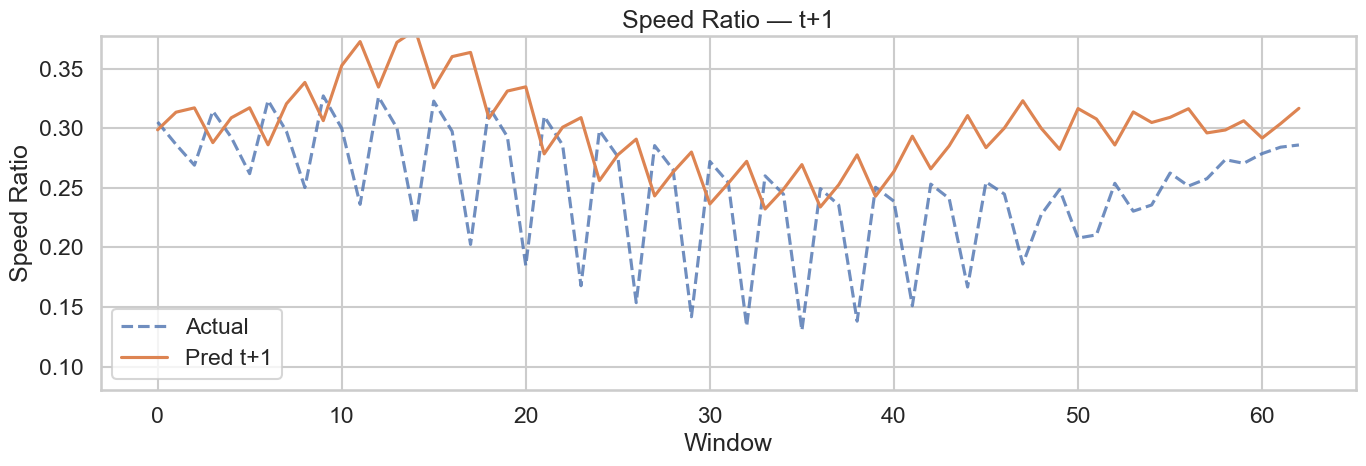

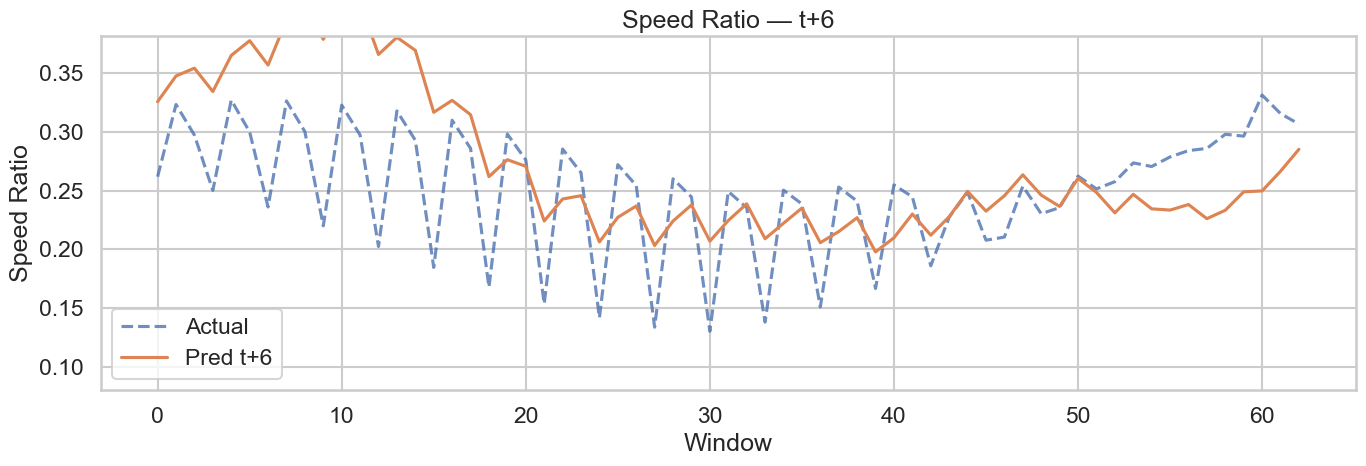

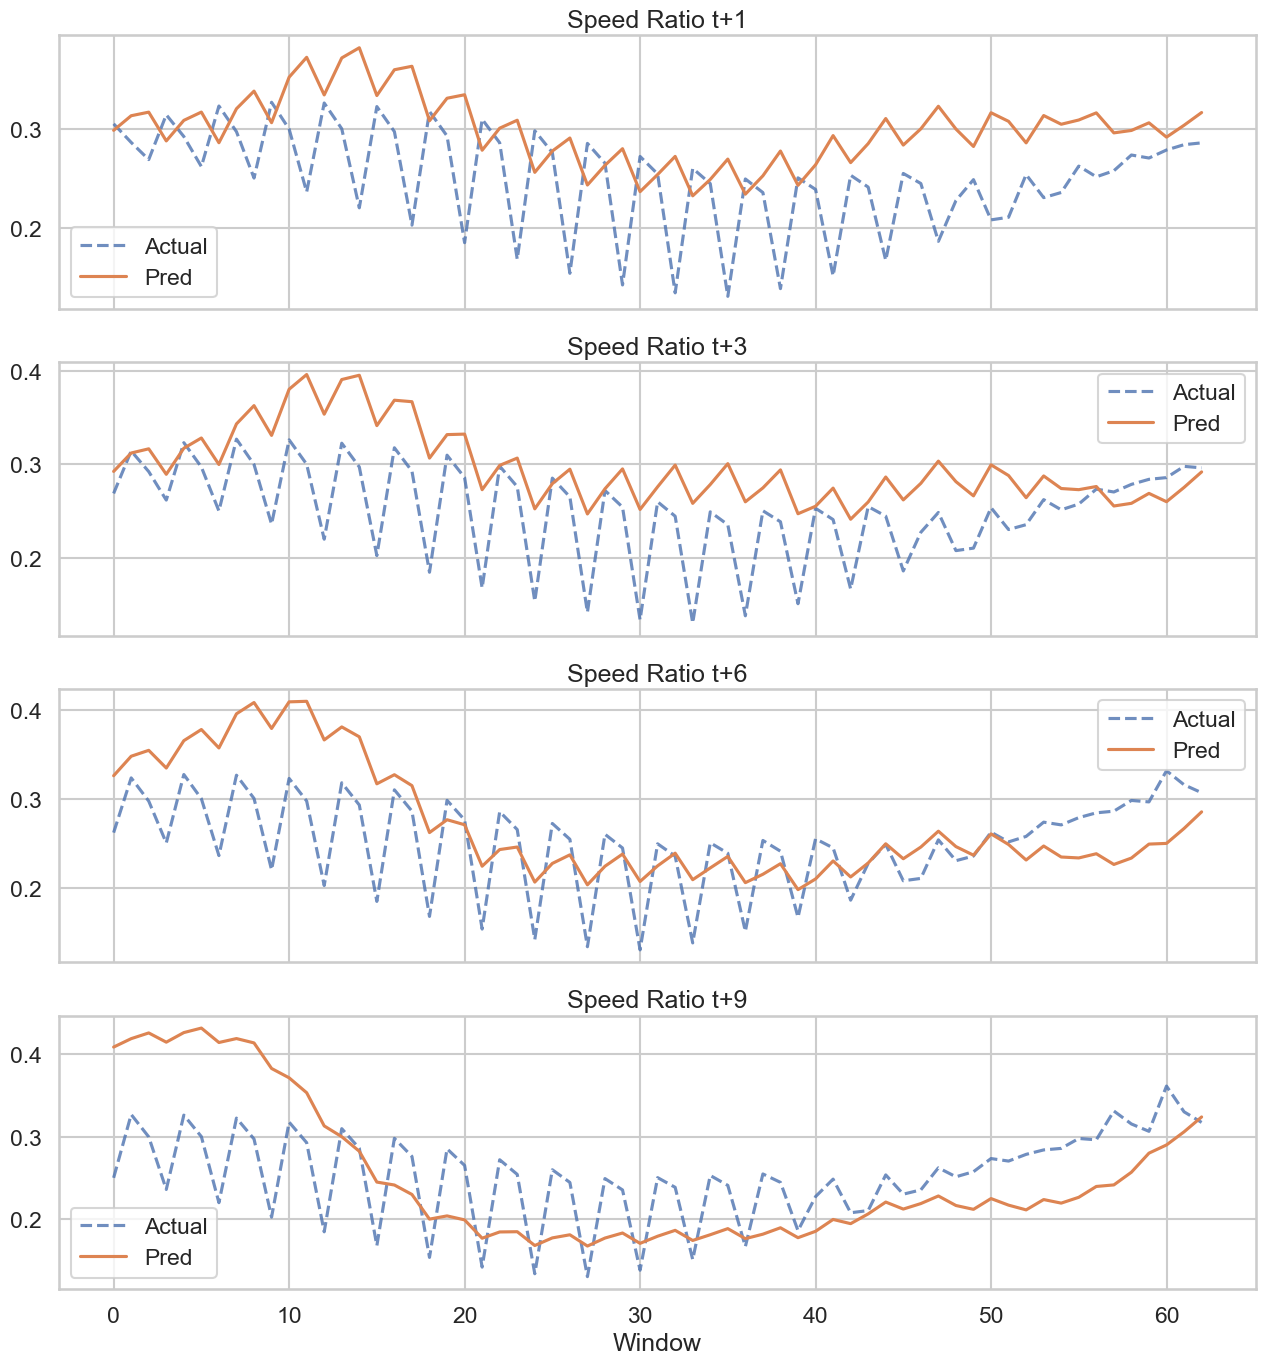

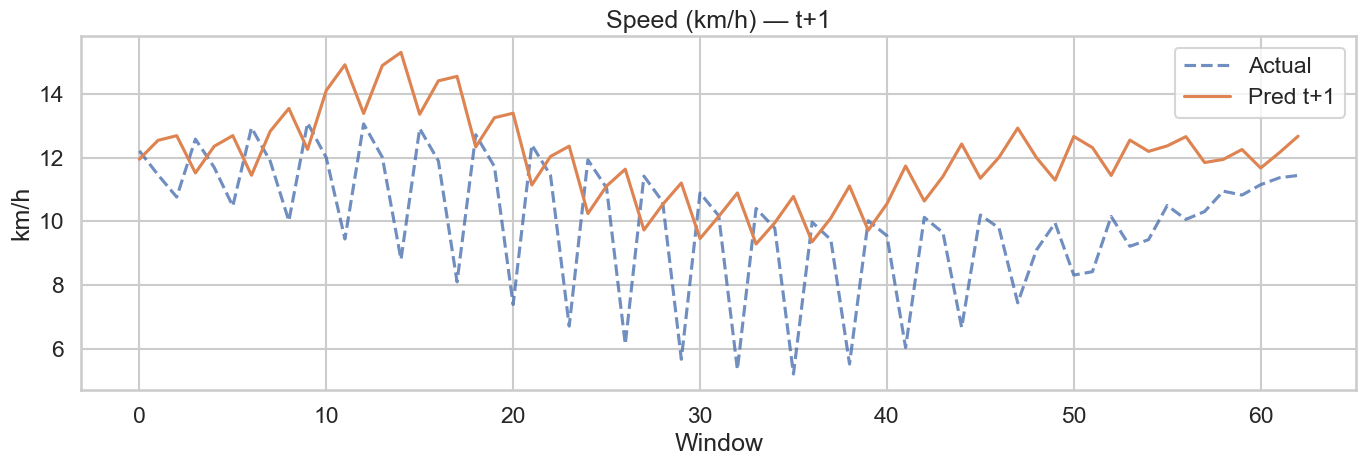

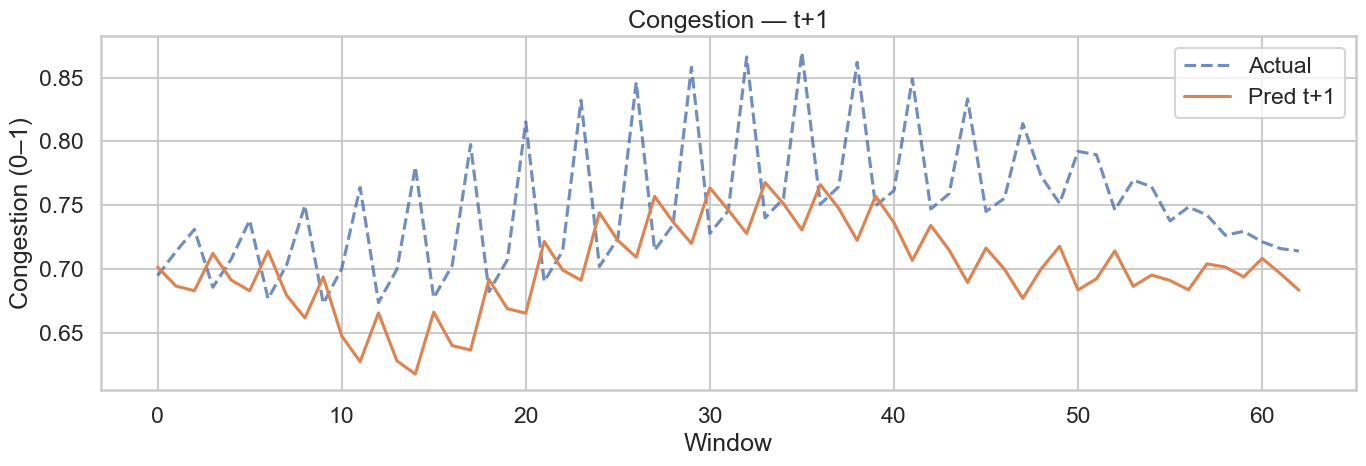

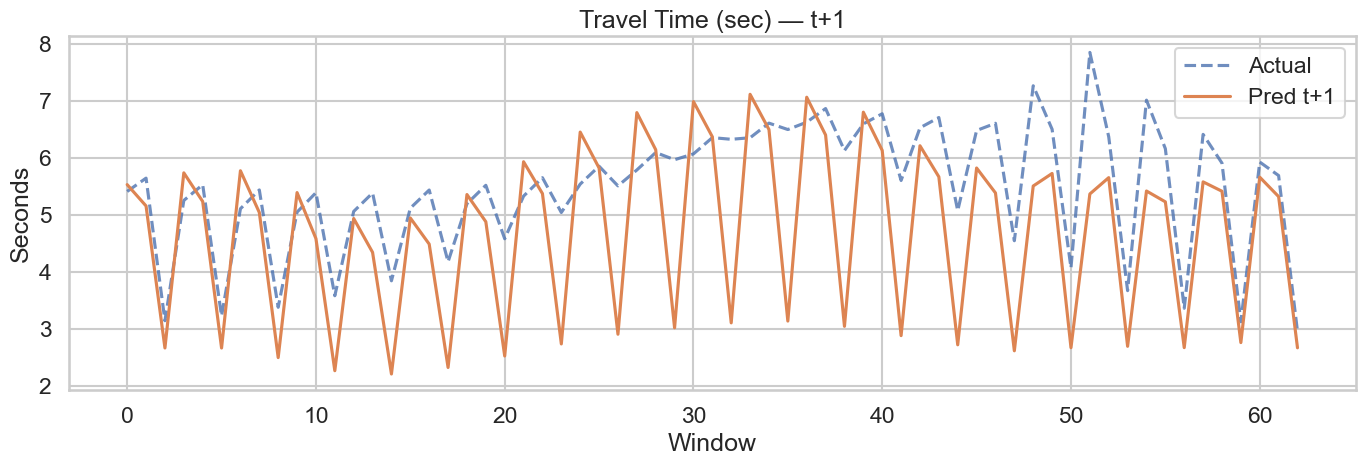

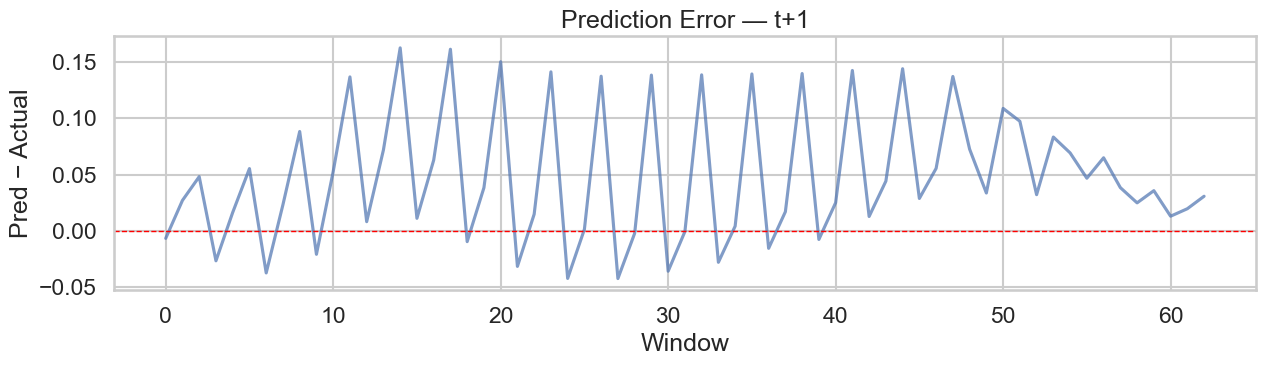

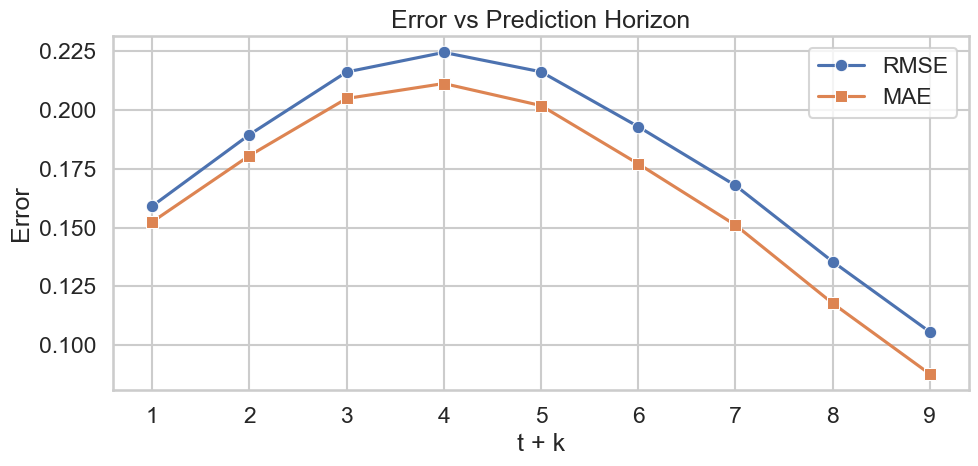

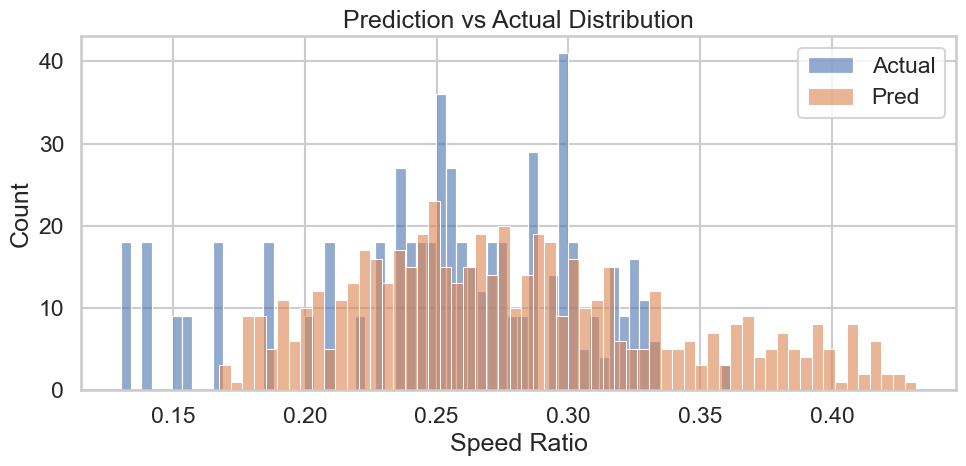

In [29]:
# # plot_speed_ratio_all(preds, actuals)
# # plot_speed_all(preds, actuals, free_flow)
# # plot_congestion_all(preds, actuals)
# # plot_travel_time_all(preds, actuals, free_flow, length)
# # plot_horizon_error(horizon_rmse,horizon_mae)
# plot_speed_ratio_single(preds, actuals, h=0)
# plot_speed_ratio_single(preds, actuals, h=5)
# plot_speed_ratio_single(preds, actuals, h=8)

# plot_error_single(preds, actuals, h=0)

# plot_speed_single(preds, actuals, free_flow, h=0)

# plot_congestion_single(preds, actuals, h=0)

# plot_travel_time_single(preds, actuals, free_flow, length, h=0)

# plot_speed_ratio_subplots(preds, actuals)

# plot_distribution(preds, actuals)
# --- single horizon (most readable) ---
plot_speed_ratio_single(preds, actuals, h=0)   # t+1
plot_speed_ratio_single(preds, actuals, h=5)   # t+6
#
# --- all 4 key horizons in subplots ---
plot_speed_ratio_subplots(preds, actuals, steps=(0, 2, 5, 8))
#
# --- speed in km/h ---
plot_speed_single(preds, actuals, ffs, h=0)
#
# --- congestion ---
plot_congestion_single(preds, actuals, h=0)
#
# --- travel time ---
plot_travel_time_single(preds, actuals, ffs, lens, h=0)
#
# --- residual error ---
plot_error_single(preds, actuals, h=0)
#
# --- error vs horizon (run after evaluate_fast) ---
plot_horizon_error(horizon_rmse, horizon_mae)
#
# --- distribution check (key: pred dist should match actual dist) ---
plot_distribution(preds, actuals)

In [30]:
torch.save(lstm.state_dict(), "lstm.pth")